# Fitting kinetic models directly on headspace ngas(t) _ ONLY pressure data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D
from matplotlib import rcParams
from scipy.signal import savgol_filter, find_peaks, correlate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit, minimize
from sklearn.metrics import mean_squared_error, r2_score
import pywt
from datetime import datetime
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import linregress
from scipy.stats import pearsonr
from scipy.constants import R
from matplotlib.patheffects import withStroke
from scipy.ndimage import gaussian_filter1d, uniform_filter1d
import seaborn as sns


In [4]:
# === Plotting ===
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
legend_font = 13
dpi = 900

# Define custom colors
colors = {
    "raw": "#009F82",        # Teal blue
    "drift": "#D95F02",      # Classic orange
    "corrected": "#7570B3",  # Soft purple (keeps consistency)
    "sg": "#E7298A",         # Magenta pink for SG-filtered

    "dwt": '#2c7bb6',        # Dark Blue
    "first": '#e66101',      # Warm Orange – mid-performing
    "logi": '#d95f02',       # Deep Red
    "gomp": "#009F82",       # Teal blue

    "dual": "#999999"        # Gray (less prominent)
}

def format_ax(ax, xlabel="Elapsed time (h)", ylabel="Pressure (kPa)"):
    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=15)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
    ax.minorticks_on()
    ax.grid(axis='y', linestyle='--', alpha=0.8)


# M1 - 2.5mM  @ RT

## First order

,Model,P_max (µmol),k (1/h),Half-Life (s),Half-Life (h),RMSE (µmol),R²,AIC,BIC
0,First-order,14.651061,0.012304,202799.019185,56.333061,1.104095,0.933834,178131.508404,178154.927365


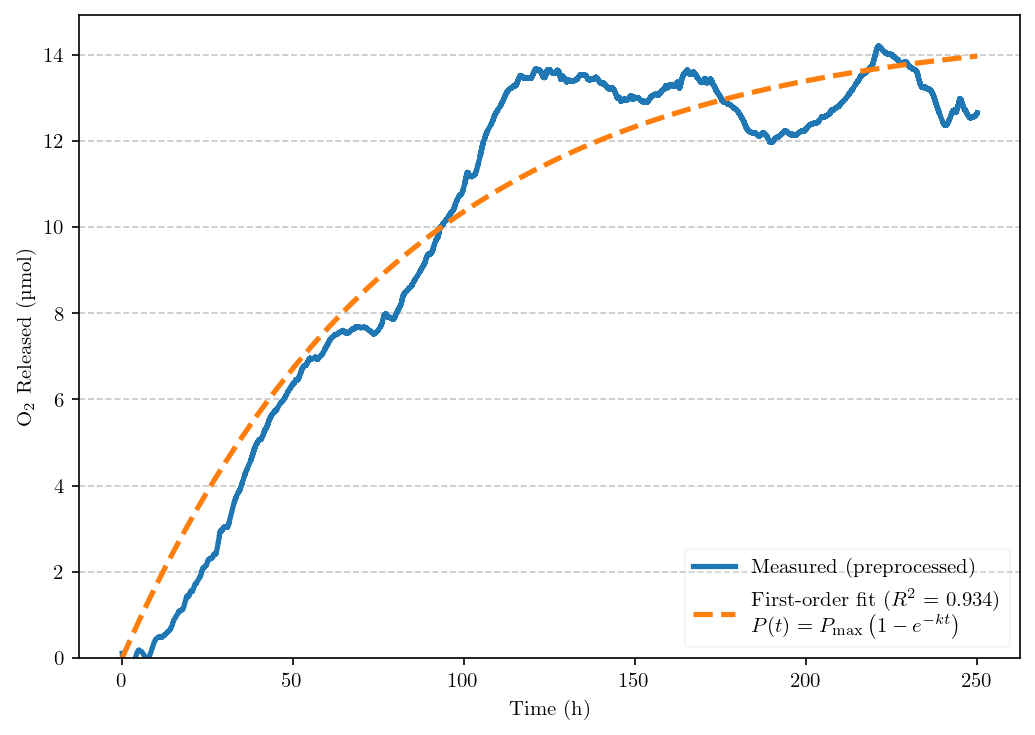

In [47]:

# ---- Load your preprocessed CSV ----
m1_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\O2_RT_released_multi_volumes.csv"
df_m1 = pd.read_csv(m1_csv)
df_m1.columns = [c.strip() for c in df_m1.columns]

# Replace these with the series/column you want to fit
ngas_m1 = df_m1["O2 Released (µmol) - Vg=4.0mL"].values
time_m1 = df_m1["Time (s)"].values

# --- Clean: drop NaNs/Infs and ensure strictly increasing time (if needed) ---
mask = np.isfinite(time_m1) & np.isfinite(ngas_m1)
t = np.asarray(time_m1[mask], dtype=float)
y = np.asarray(ngas_m1[mask], dtype=float)

# If times are not strictly increasing, sort them (and y accordingly)
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y = t[order], y[order]

# Optionally, shift time to start at 0 for numerical stability (doesn't change k)
t0 = t.min()
t = t - t0

# --- First-order model ---
def first_order_model(t, P_max, k):
    # P(t) = P_max * (1 - exp(-k t))
    return P_max * (1.0 - np.exp(-k * t))

# --- Fit: robust initial guesses + nonnegative bounds ---
Pmax0 = float(np.nanmax(y))
dt = max(t.max() - t.min(), 1.0)  # seconds span; guard against zero
# choose half-life ~ 30% of data span as a reasonable default
k0 = np.log(2.0) / (0.3 * dt)
k0 = max(k0, 1e-9)

popt, pcov = curve_fit(
    first_order_model, t, y,
    p0=[Pmax0 if np.isfinite(Pmax0) and Pmax0 > 0 else (y[-1] if len(y) else 1.0), k0],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
    maxfev=20000
)
P_max_fit, k_fit = popt
y_fit = first_order_model(t, *popt)

# --- Metrics (first-order only) ---
def aic(n, rss, k_params):
    return n * np.log(rss / n) + 2 * k_params

def bic(n, rss, k_params):
    return n * np.log(rss / n) + k_params * np.log(n)

n = len(y)
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
aic_val = aic(n, rss, 2)  # params: P_max, k
bic_val = bic(n, rss, 2)
t_half_h = np.log(2.0) / k_fit
t_half_s = t_half_h * 3600.0

# --- Show metrics ---
metrics = pd.DataFrame({
    "Model": ["First-order"],
    "P_max (µmol)": [P_max_fit],
    "k (1/h)": [k_fit],
    "Half-Life (s)": [t_half_s],
    "Half-Life (h)": [t_half_h],
    "RMSE (µmol)": [rmse],
    "R²": [r2],
    "AIC": [aic_val],
    "BIC": [bic_val],
})
display(metrics.round(6))

# --- Plot (Plot #3 analog: data + first-order fit only) ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t + t0, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t + t0, y_fit, "--", lw=2.5,
         label=fr"First-order fit ($R^2$ = {r2:.3f})" + "\n" + r"$P(t)=P_{\max}\left(1-e^{-kt}\right)$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.xlim()
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# Logistic

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC
0,Logistic (bounded),13.182843,0.043771,59.024291,0.770846,0.967748,-468159.844205,-468124.715762


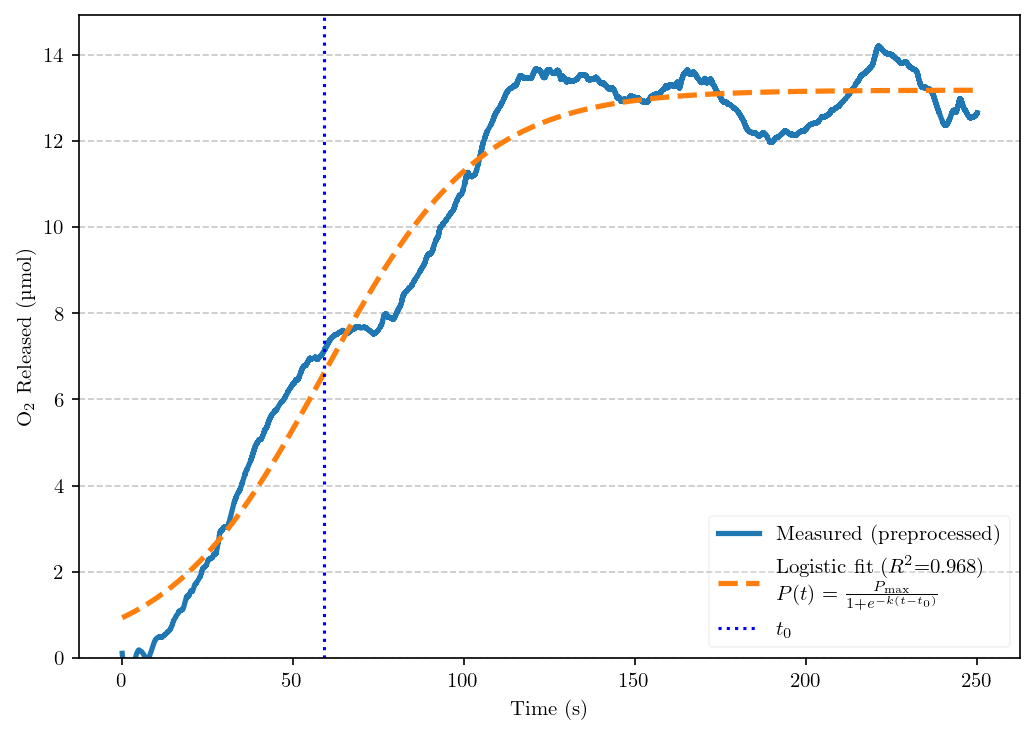

In [49]:

# ---- Load your preprocessed CSV ----
mlogi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\O2_RT_released_multi_volumes.csv"
df_mlogi = pd.read_csv(mlogi_csv)
df_mlogi.columns = [c.strip() for c in df_mlogi.columns]

# Replace these with the series/column you want to fit
ngas_mlogi = df_mlogi["O2 Released (µmol) - Vg=4.0mL"].values
time_mlogi = df_mlogi["Time (s)"].values

# --- Clean NaNs/Infs ---
mask = np.isfinite(time_mlogi) & np.isfinite(ngas_mlogi)
t = np.asarray(time_mlogi[mask], dtype=float)
y = np.asarray(ngas_mlogi[mask], dtype=float)

# --- Logistic model ---
def logistic_model(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))

# --- Fit function with bounds from table ---
def fit_logistic_model(time, signal):
    P_max = np.max(signal)
    # initial guess for t0 = time at ~half max
    P0_init = time[np.argmin(np.abs(signal - P_max / 2.0))]
    k_init = 1.0 / (time[-1] - time[0] + 1e-9)  # avoid div/0
    
    # bounds according to table:
    # t0: [0.8 * P0_init, 1.2 * P0_init]
    # k: [0, 1]
    # P_max: [0.8 * P_max, 1.2 * P_max]
    bounds = [
        (0.8 * P0_init, 1.2 * P0_init),
        (0.0, 1.0),
        (0.8 * P_max, 1.2 * P_max)
    ]
    
    res = minimize(
        lambda p: mean_squared_error(signal, logistic_model(time, *p)),
        [P0_init, k_init, P_max],
        bounds=bounds
    )
    popt = res.x
    fit = logistic_model(time, *popt)
    return popt, fit

# --- Run fit ---
popt, y_fit = fit_logistic_model(t, y)
t0_fit, k_fit, Pmax_fit = popt

# --- Metrics ---
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 3
bic = n * np.log(rss / n) + 3 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Logistic (bounded)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/h)": [k_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic]
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic fit ($R^2$={r2:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit, linestyle=":", color="blue", label=r"$t_0$")
plt.xlabel("Time (s)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# Gompertz

,Model,P_max (µmol),k (1/s),λ (lag),RMSE,R²,AIC,BIC
0,Gompertz,13.329875,0.030748,1.364407,0.755083,0.969054,-505324.524451,-505289.396008


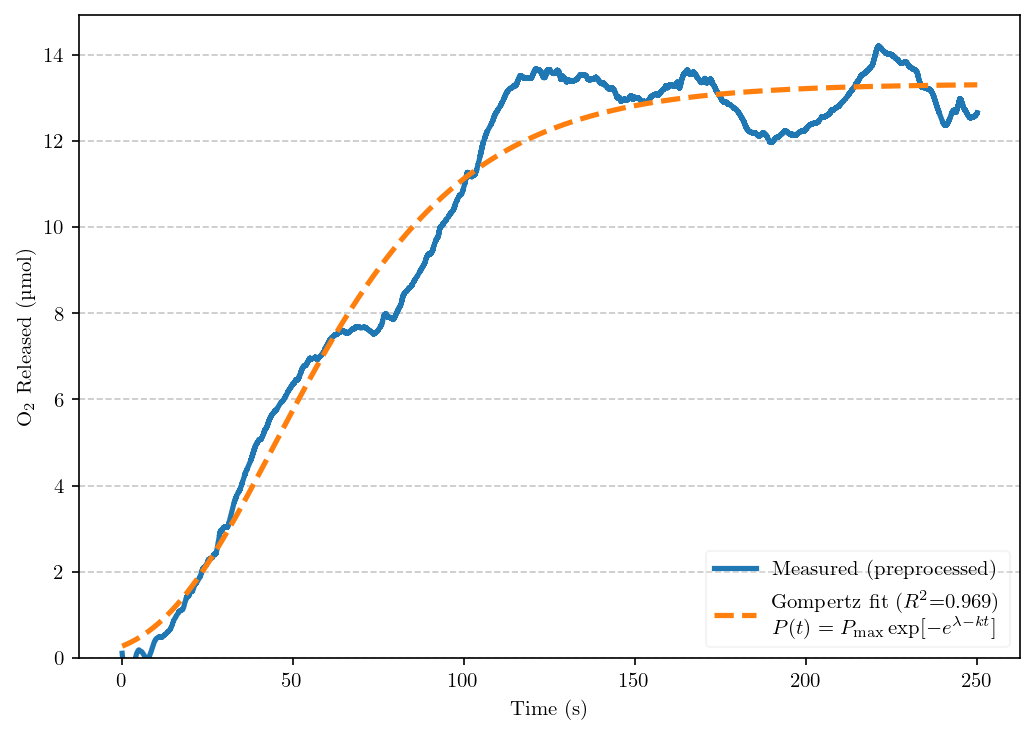

In [ ]:

m1gom_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\O2_RT_released_multi_volumes.csv"
df_m1gom = pd.read_csv(m1gom_csv)
df_m1gom.columns = [c.strip() for c in df_m1gom.columns]

ngas_m1gom = df_m1gom["O2 Released (µmol) - Vg=4.0mL"].values
time_m1gom = df_m1gom["Time (s)"].values 

# Clean 
mask = np.isfinite(time_m1gom) & np.isfinite(ngas_m1gom)
t_m1gom = np.asarray(time_m1gom[mask], dtype=float)
y_m1gom = np.asarray(ngas_m1gom[mask], dtype=float)


def gompertz_model_m1gom(t, P_max, k, lam):
    return P_max * np.exp(-np.exp(lam - k * t))


Pmax0_m1gom = np.max(y_m1gom)
k0_m1gom = 1.0 / (t_m1gom[-1] - t_m1gom[0])
lam0_m1gom = np.log(np.log(Pmax0_m1gom / max(y_m1gom[0], 1e-9) + 1))  # heuristic guess
#++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
p0_m1gom = [Pmax0_m1gom, k0_m1gom, lam0_m1gom]


popt_m1gom, pcov_m1gom = curve_fit(
    gompertz_model_m1gom, t_m1gom, y_m1gom, p0=p0_m1gom,
    bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]),
    maxfev=20000
)
Pmax_fit_m1gom, k_fit_m1gom, lam_fit_m1gom = popt_m1gom
y_fit_m1gom = gompertz_model_m1gom(t_m1gom, *popt_m1gom)


rss_m1gom = np.sum((y_m1gom - y_fit_m1gom) ** 2)
rmse_m1gom = np.sqrt(mean_squared_error(y_m1gom, y_fit_m1gom))
r2_m1gom = r2_score(y_m1gom, y_fit_m1gom)
n_m1gom = len(y_m1gom)
aic_m1gom = n_m1gom * np.log(rss_m1gom / n_m1gom) + 2 * 3
bic_m1gom = n_m1gom * np.log(rss_m1gom / n_m1gom) + 3 * np.log(n_m1gom)

metrics_m1gom = pd.DataFrame({
    "Model": ["Gompertz"],
    "P_max (µmol)": [Pmax_fit_m1gom],
    "k (1/s)": [k_fit_m1gom],
    "λ (lag)": [lam_fit_m1gom],
    "RMSE": [rmse_m1gom],
    "R²": [r2_m1gom],
    "AIC": [aic_m1gom],
    "BIC": [bic_m1gom]
})
display(metrics_m1gom.round(6))


plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t_m1gom, y_m1gom, label="Measured (preprocessed)", lw=2.5)
plt.plot(t_m1gom, y_fit_m1gom, "--", lw=2.5,
         label=fr"Gompertz fit ($R^2$={r2_m1gom:.3f})" + "\n" + r"$P(t)=P_{\max}\exp[-e^{\lambda - kt}]$")
plt.xlabel("Time (s)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# M2 - 2.18mM @ RT

# First order

,Model,P_max (µmol),k (1/h),Half-Life (s),Half-Life (h),RMSE (µmol),R²,AIC,BIC
0,First-order,11.434695,0.008731,285800.339069,79.388983,0.990866,0.90927,-15951.365376,-15928.014141


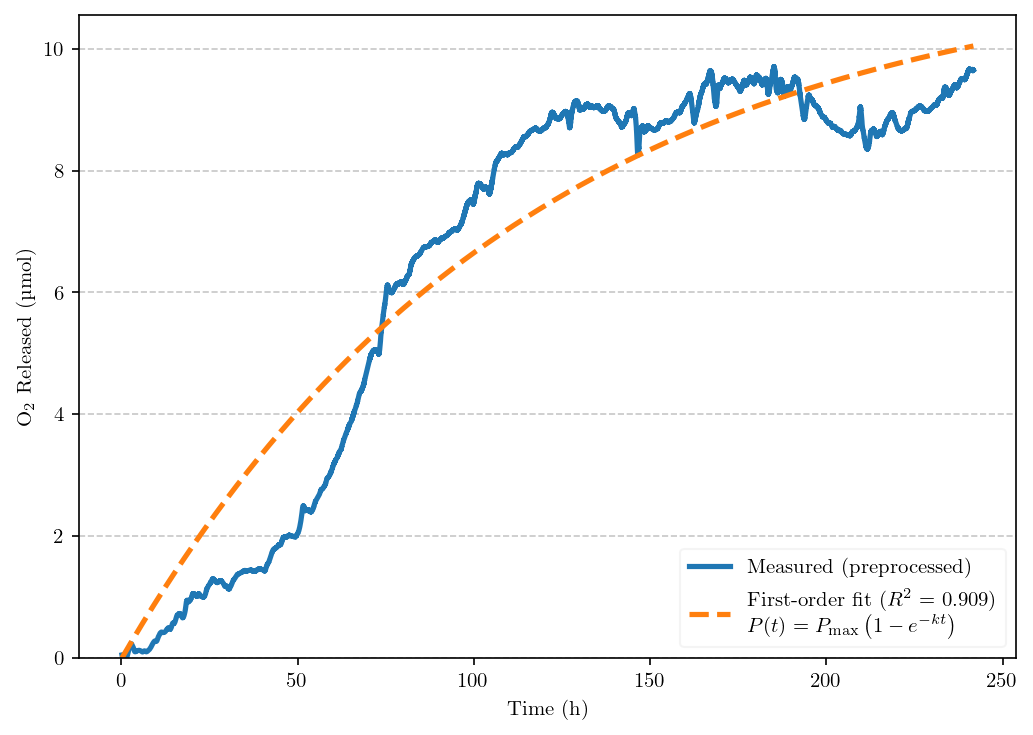

In [46]:
m2_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\RT\data files\O2_released_multi_volumes.csv"
df_m2 = pd.read_csv(m2_csv)
df_m2.columns = [c.strip() for c in df_m2.columns]

# Replace these with the series/column you want to fit
ngas_m2 = df_m2["O2 Released (µmol) - Vg=4.0mL"].values
time_m2 = df_m2["Time (s)"].values



# --- Clean: drop NaNs/Infs and ensure strictly increasing time (if needed) ---
mask = np.isfinite(time_m2) & np.isfinite(ngas_m2)
t = np.asarray(time_m2[mask], dtype=float)
y = np.asarray(ngas_m2[mask], dtype=float)

# If times are not strictly increasing, sort them (and y accordingly)
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y = t[order], y[order]

# Optionally, shift time to start at 0 for numerical stability (doesn't change k)
t0 = t.min()
t = t - t0

# --- First-order model ---
def first_order_model(t, P_max, k):
    # P(t) = P_max * (1 - exp(-k t))
    return P_max * (1.0 - np.exp(-k * t))

# --- Fit: robust initial guesses + nonnegative bounds ---
Pmax0 = float(np.nanmax(y))
dt = max(t.max() - t.min(), 1.0)  # seconds span; guard against zero
# choose half-life ~ 30% of data span as a reasonable default
k0 = np.log(2.0) / (0.3 * dt)
k0 = max(k0, 1e-9)

popt, pcov = curve_fit(
    first_order_model, t, y,
    p0=[Pmax0 if np.isfinite(Pmax0) and Pmax0 > 0 else (y[-1] if len(y) else 1.0), k0],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
    maxfev=20000
)
P_max_fit, k_fit = popt
y_fit = first_order_model(t, *popt)

# --- Metrics (first-order only) ---
def aic(n, rss, k_params):
    return n * np.log(rss / n) + 2 * k_params

def bic(n, rss, k_params):
    return n * np.log(rss / n) + k_params * np.log(n)

n = len(y)
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
aic_val = aic(n, rss, 2)  # params: P_max, k
bic_val = bic(n, rss, 2)
t_half_h = np.log(2.0) / k_fit
t_half_s = t_half_h * 3600.0

# --- Show metrics ---
metrics = pd.DataFrame({
    "Model": ["First-order"],
    "P_max (µmol)": [P_max_fit],
    "k (1/h)": [k_fit],
    "Half-Life (s)": [t_half_s],
    "Half-Life (h)": [t_half_h],
    "RMSE (µmol)": [rmse],
    "R²": [r2],
    "AIC": [aic_val],
    "BIC": [bic_val],
})
display(metrics.round(6))

# --- Plot (Plot #3 analog: data + first-order fit only) ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t + t0, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t + t0, y_fit, "--", lw=2.5,
         label=fr"First-order fit ($R^2$ = {r2:.3f})" + "\n" + r"$P(t)=P_{\max}\left(1-e^{-kt}\right)$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.xlim()
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Logistic

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC
0,Logistic (bounded),9.11616,0.05528,68.853303,0.278473,0.992834,-2.223063e+06,-2.223028e+06


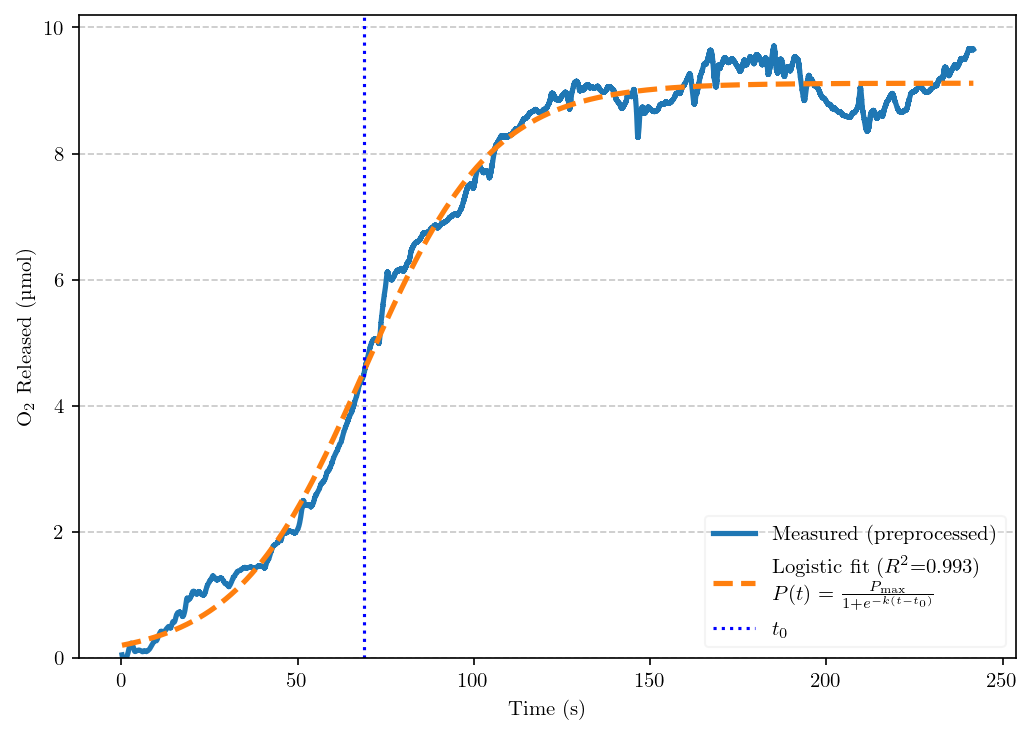

In [48]:

# ---- Load your preprocessed CSV ----
m2logi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\RT\data files\O2_released_multi_volumes.csv"
df_m2logi = pd.read_csv(m2logi_csv)
df_m2logi.columns = [c.strip() for c in df_m2logi.columns]

# Replace these with the series/column you want to fit
ngas_m2logi = df_m2logi["O2 Released (µmol) - Vg=4.0mL"].values
time_m2logi = df_m2logi["Time (s)"].values

# --- Clean NaNs/Infs ---
mask = np.isfinite(time_m2logi) & np.isfinite(ngas_m2logi)
t = np.asarray(time_m2logi[mask], dtype=float)
y = np.asarray(ngas_m2logi[mask], dtype=float)

# --- Logistic model ---
def logistic_model(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))

# --- Fit function with bounds from table ---
def fit_logistic_model(time, signal):
    P_max = np.max(signal)
    # initial guess for t0 = time at ~half max
    P0_init = time[np.argmin(np.abs(signal - P_max / 2.0))]
    k_init = 1.0 / (time[-1] - time[0] + 1e-9)  # avoid div/0
    
    # bounds according to table:
    # t0: [0.8 * P0_init, 1.2 * P0_init]
    # k: [0, 1]
    # P_max: [0.8 * P_max, 1.2 * P_max]
    bounds = [
        (0.8 * P0_init, 1.2 * P0_init),
        (0.0, 1.0),
        (0.8 * P_max, 1.2 * P_max)
    ]
    
    res = minimize(
        lambda p: mean_squared_error(signal, logistic_model(time, *p)),
        [P0_init, k_init, P_max],
        bounds=bounds
    )
    popt = res.x
    fit = logistic_model(time, *popt)
    return popt, fit

# --- Run fit ---
popt, y_fit = fit_logistic_model(t, y)
t0_fit, k_fit, Pmax_fit = popt

# --- Metrics ---
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 3
bic = n * np.log(rss / n) + 3 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Logistic (bounded)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/h)": [k_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic]
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic fit ($R^2$={r2:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit, linestyle=":", color="blue", label=r"$t_0$")
plt.xlabel("Time (s)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Gompertz

# M2 - 2.18mM @ 37 C

## First order

,Model,P_max (µmol),k (1/h),Half-Life (s),Half-Life (h),RMSE (µmol),R²,AIC,BIC
0,First-order,10.383359,0.052222,47782.987586,13.273052,0.206732,0.993661,-1.002539e+06,-1.002517e+06


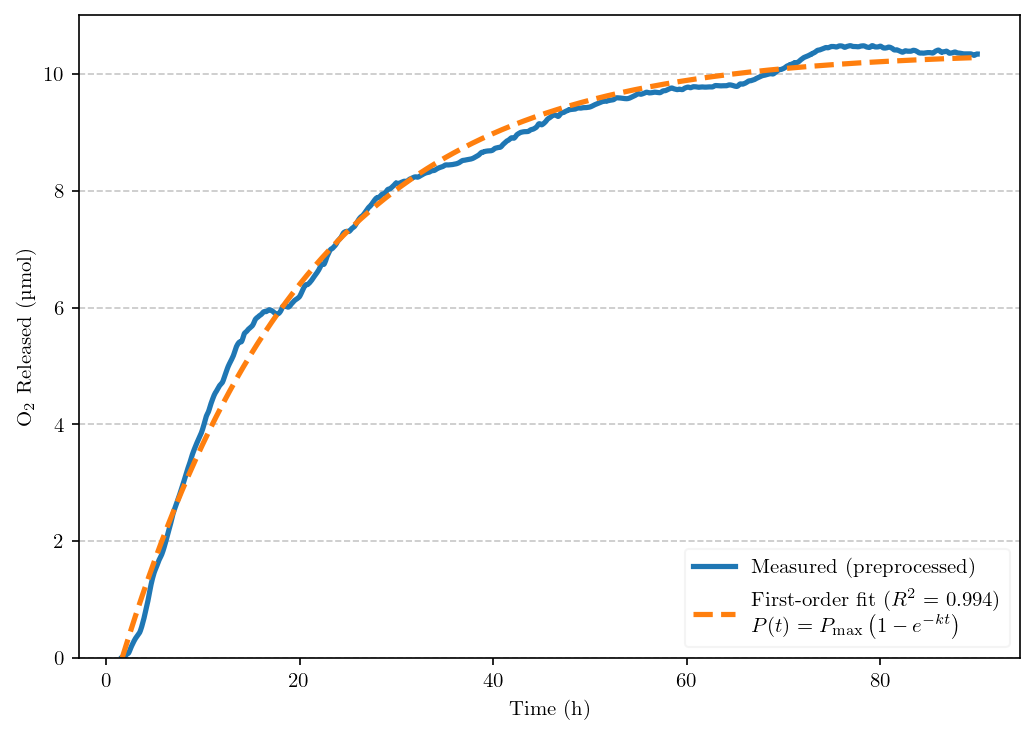

In [45]:
m22_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 2\2_O2_37DEG_released_multi_volumes.csv"
df_m22 = pd.read_csv(m22_csv)
df_m22.columns = [c.strip() for c in df_m22.columns]

# Replace these with the series/column you want to fit
ngas_m22 = df_m22["O2 Released (µmol) - Vg=4.0mL"].values
time_m22 = df_m22["Time (h)"].values


# --- Clean: drop NaNs/Infs and ensure strictly increasing time (if needed) ---
mask = np.isfinite(time_m22) & np.isfinite(ngas_m22)
t = np.asarray(time_m22[mask], dtype=float)
y = np.asarray(ngas_m22[mask], dtype=float)

# If times are not strictly increasing, sort them (and y accordingly)
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y = t[order], y[order]

# Optionally, shift time to start at 0 for numerical stability (doesn't change k)
t0 = t.min()
t = t - t0

# --- First-order model ---
def first_order_model(t, P_max, k):
    # P(t) = P_max * (1 - exp(-k t))
    return P_max * (1.0 - np.exp(-k * t))

# --- Fit: robust initial guesses + nonnegative bounds ---
Pmax0 = float(np.nanmax(y))
dt = max(t.max() - t.min(), 1.0)  # seconds span; guard against zero
# choose half-life ~ 30% of data span as a reasonable default
k0 = np.log(2.0) / (0.3 * dt)
k0 = max(k0, 1e-9)

popt, pcov = curve_fit(
    first_order_model, t, y,
    p0=[Pmax0 if np.isfinite(Pmax0) and Pmax0 > 0 else (y[-1] if len(y) else 1.0), k0],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
    maxfev=20000
)
P_max_fit, k_fit = popt
y_fit = first_order_model(t, *popt)

# --- Metrics (first-order only) ---
def aic(n, rss, k_params):
    return n * np.log(rss / n) + 2 * k_params

def bic(n, rss, k_params):
    return n * np.log(rss / n) + k_params * np.log(n)

n = len(y)
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
aic_val = aic(n, rss, 2)  # params: P_max, k
bic_val = bic(n, rss, 2)
t_half_h = np.log(2.0) / k_fit
t_half_s = t_half_h * 3600.0

# --- Show metrics ---
metrics = pd.DataFrame({
    "Model": ["First-order"],
    "P_max (µmol)": [P_max_fit],
    "k (1/h)": [k_fit],
    "Half-Life (s)": [t_half_s],
    "Half-Life (h)": [t_half_h],
    "RMSE (µmol)": [rmse],
    "R²": [r2],
    "AIC": [aic_val],
    "BIC": [bic_val],
})
display(metrics.round(6))

# --- Plot (Plot #3 analog: data + first-order fit only) ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t + t0, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t + t0, y_fit, "--", lw=2.5,
         label=fr"First-order fit ($R^2$ = {r2:.3f})" + "\n" + r"$P(t)=P_{\max}\left(1-e^{-kt}\right)$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.xlim()
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Logistic

,Model,P_max (µmol),k (1/s),t0 (s),RMSE,R²,AIC,BIC
0,Logistic (bounded),10.011575,0.10356,15.813028,0.499658,0.962972,-441269.280885,-441237.271474


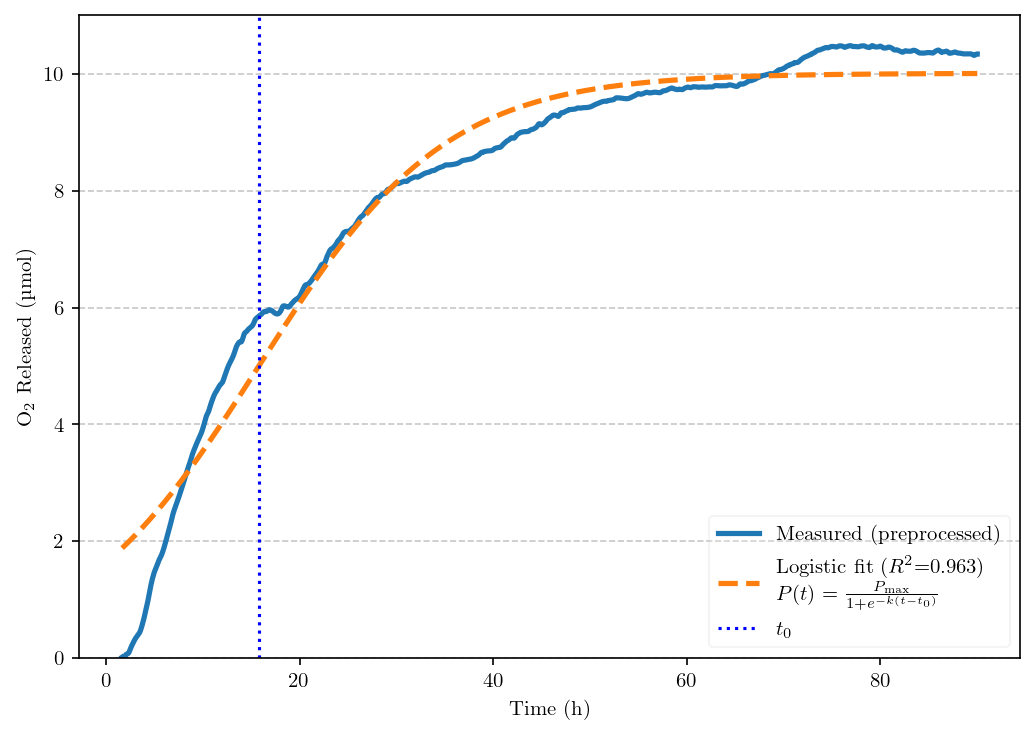

In [20]:


m22logi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 2\2_O2_37DEG_released_multi_volumes.csv"
df_m22logi = pd.read_csv(m22logi_csv)
df_m22logi.columns = [c.strip() for c in df_m22logi.columns]

# Replace these with the series/column you want to fit
ngas_m22logi = df_m22logi["O2 Released (µmol) - Vg=4.0mL"].values
time_m22logi = df_m22logi["Time (h)"].values

# --- Clean NaNs/Infs ---
mask = np.isfinite(time_m22logi) & np.isfinite(ngas_m22logi)
t = np.asarray(time_m22logi[mask], dtype=float)
y = np.asarray(ngas_m22logi[mask], dtype=float)

# --- Logistic model ---
def logistic_model(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))

# --- Fit function with bounds from table ---
def fit_logistic_model(time, signal):
    P_max = np.max(signal)
    # initial guess for t0 = time at ~half max
    P0_init = time[np.argmin(np.abs(signal - P_max / 2.0))]
    k_init = 1.0 / (time[-1] - time[0] + 1e-9)  # avoid div/0
    
    # bounds according to table:
    # t0: [0.8 * P0_init, 1.2 * P0_init]
    # k: [0, 1]
    # P_max: [0.8 * P_max, 1.2 * P_max]
    bounds = [
        (0.8 * P0_init, 1.2 * P0_init),
        (0.0, 1.0),
        (0.8 * P_max, 1.2 * P_max)
    ]
    
    res = minimize(
        lambda p: mean_squared_error(signal, logistic_model(time, *p)),
        [P0_init, k_init, P_max],
        bounds=bounds
    )
    popt = res.x
    fit = logistic_model(time, *popt)
    return popt, fit

# --- Run fit ---
popt, y_fit = fit_logistic_model(t, y)
t0_fit, k_fit, Pmax_fit = popt

# --- Metrics ---
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 3
bic = n * np.log(rss / n) + 3 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Logistic (bounded)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/s)": [k_fit],
    "t0 (s)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic]
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic fit ($R^2$={r2:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit, linestyle=":", color="blue", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Modified logistic

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC,Converged
0,Logistic (robust),5.127742,0.113017,15.851163,0.255508,0.96644,-774074.935966,-774043.269477,True


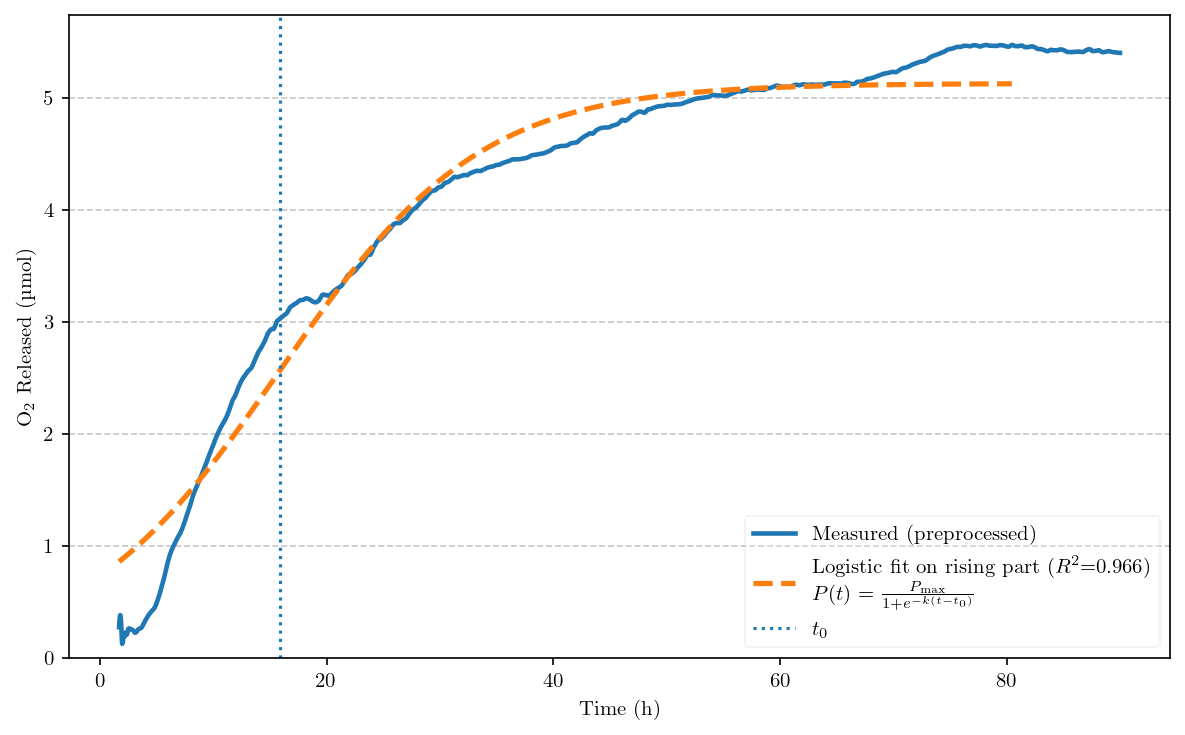

In [52]:
modified_logi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 2\2_O2_37DEG_released_multi_volumes.csv"
df_modified_logi = pd.read_csv(modified_logi_csv)
df_modified_logi.columns = [c.strip() for c in df_modified_logi.columns]

# Keep only positive O2 rows so time & signal stay aligned
df_modified_logi_pos = df_modified_logi[df_modified_logi["O2 Released (µmol)"] > 0].reset_index(drop=True)
t_full = df_modified_logi_pos["Time (h)"].to_numpy(dtype=float)
y_full = df_modified_logi_pos["O2 Released (µmol)"].to_numpy(dtype=float)


mask = np.isfinite(t_full) & np.isfinite(y_full)
t_full = t_full[mask]
y_full = y_full[mask]

idx_peak = np.argmax(y_full)
t = t_full[: idx_peak + 1]
y = y_full[: idx_peak + 1]


def logistic_model(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))


span = max(t.max() - t.min(), 1e-6)
Pmax0 = np.quantile(y, 0.98)  

# smooth just for slope estimation (doesn't affect fit)
win = max(5, int(0.03 * len(y)))  # ~3% of points
if win % 2 == 0:
    win += 1
y_smooth = pd.Series(y).rolling(window=win, center=True, min_periods=1).mean().to_numpy()
dy_dt = np.gradient(y_smooth, t)
i_inflect = int(np.argmax(dy_dt))
t0_init = float(t[i_inflect])
slope_max = float(max(dy_dt[i_inflect], 1e-12))  # avoid 0


# For logistic, slope at inflection ≈ k * Pmax / 4 -> k ≈ 4*slope/Pmax
k_init = float(4.0 * slope_max / max(Pmax0, 1e-9))
# keep k_init within a sane range w.r.t span
k_init = np.clip(k_init, 1e-6, 10.0 / span)


bounds = [
    (t.min(), t.max()),                 
    (1e-6, 10.0 / span),                
    (0.5 * Pmax0, 2.0 * max(y))         
]


def fit_logistic_model(time, signal):
    def obj(p):
        return mean_squared_error(signal, logistic_model(time, *p))
    x0 = np.array([t0_init, k_init, Pmax0], dtype=float)
    res = minimize(obj, x0, bounds=bounds, method="L-BFGS-B")
    # If optimizer struggles, fall back to a gentler start
    if not res.success:
        alt_x0 = np.array([np.median(time), 1.0 / span, np.max(signal)], dtype=float)
        res = minimize(obj, alt_x0, bounds=bounds, method="L-BFGS-B")
    popt = res.x
    fit = logistic_model(time, *popt)
    return popt, fit, res

popt, y_fit, res = fit_logistic_model(t, y)
t0_fit, k_fit, Pmax_fit = popt

# ---- Metrics ----
rss = np.sum((y - y_fit) ** 2)
rmse = float(np.sqrt(mean_squared_error(y, y_fit)))
r2 = float(r2_score(y, y_fit))
n = len(y)
aic = float(n * np.log(rss / n + 1e-12) + 2 * 3)
bic = float(n * np.log(rss / n + 1e-12) + 3 * np.log(max(n, 2)))

metrics = pd.DataFrame({
    "Model": ["Logistic (robust)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/h)": [k_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic],
    "Converged": [bool(res.success)]
})
display(metrics.round(6))


plt.figure(figsize=(8, 5), dpi=150)
plt.plot(t_full, y_full, label="Measured (preprocessed)", lw=2.2)  # show full series for context
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic fit on rising part ($R^2$={r2:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Gompertz

# M3 - 1.2mM @ RT

## First order

,Model,P_max (µmol),k (1/h),Half-Life (s),Half-Life (h),RMSE (µmol),R²,AIC,BIC
0,First-order,3.958929,0.050603,49311.499776,13.697639,0.700288,0.587449,-602437.601363,-602414.305994


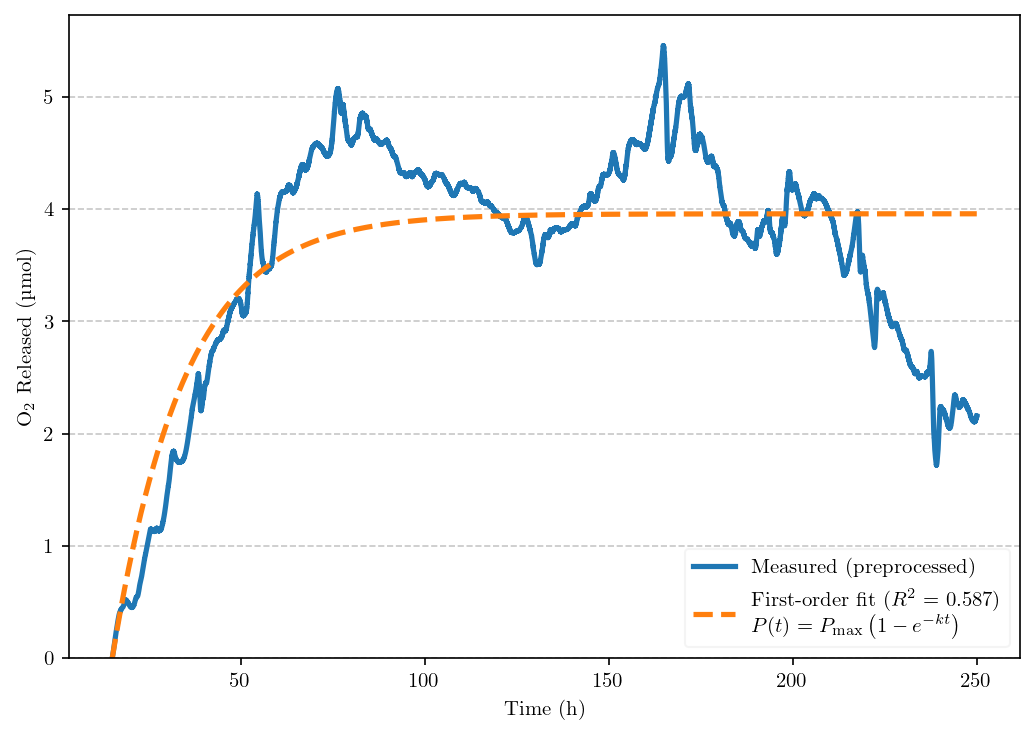

In [42]:
m3_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\RT\Data files\M3_1.2mM_RT_pressure_o2_release.csv"
df_m3 = pd.read_csv(m3_csv)
df_m3.columns = [c.strip() for c in df_m3.columns]

# Replace these with the series/column you want to fit

df_m3_pos = df_m3[df_m3["O2 Released (µmol)"] > 0].reset_index(drop=True)

ngas_m3 = df_m3_pos["O2 Released (µmol)"].values
time_m3 = df_m3_pos["Time (h)"].values


# --- Clean: drop NaNs/Infs and ensure strictly increasing time (if needed) ---
mask = np.isfinite(time_m3) & np.isfinite(ngas_m3)
t = np.asarray(time_m3[mask], dtype=float)
y = np.asarray(ngas_m3[mask], dtype=float)

# If times are not strictly increasing, sort them (and y accordingly)
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y = t[order], y[order]

# Optionally, shift time to start at 0 for numerical stability (doesn't change k)
t0 = t.min()
t = t - t0

# --- First-order model ---
def first_order_model(t, P_max, k):
    # P(t) = P_max * (1 - exp(-k t))
    return P_max * (1.0 - np.exp(-k * t))

# --- Fit: robust initial guesses + nonnegative bounds ---
Pmax0 = float(np.nanmax(y))
dt = max(t.max() - t.min(), 1.0)  # seconds span; guard against zero
# choose half-life ~ 30% of data span as a reasonable default
k0 = np.log(2.0) / (0.3 * dt)
k0 = max(k0, 1e-9)

popt, pcov = curve_fit(
    first_order_model, t, y,
    p0=[Pmax0 if np.isfinite(Pmax0) and Pmax0 > 0 else (y[-1] if len(y) else 1.0), k0],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
    maxfev=20000
)
P_max_fit, k_fit = popt
y_fit = first_order_model(t, *popt)

# --- Metrics (first-order only) ---
def aic(n, rss, k_params):
    return n * np.log(rss / n) + 2 * k_params

def bic(n, rss, k_params):
    return n * np.log(rss / n) + k_params * np.log(n)

n = len(y)
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
aic_val = aic(n, rss, 2)  # params: P_max, k
bic_val = bic(n, rss, 2)
t_half_h = np.log(2.0) / k_fit
t_half_s = t_half_h * 3600.0

# --- Show metrics ---
metrics = pd.DataFrame({
    "Model": ["First-order"],
    "P_max (µmol)": [P_max_fit],
    "k (1/h)": [k_fit],
    "Half-Life (s)": [t_half_s],
    "Half-Life (h)": [t_half_h],
    "RMSE (µmol)": [rmse],
    "R²": [r2],
    "AIC": [aic_val],
    "BIC": [bic_val],
})
display(metrics.round(6))

# --- Plot (Plot #3 analog: data + first-order fit only) ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t + t0, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t + t0, y_fit, "--", lw=2.5,
         label=fr"First-order fit ($R^2$ = {r2:.3f})" + "\n" + r"$P(t)=P_{\max}\left(1-e^{-kt}\right)$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.xlim()
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Logistic

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC
0,Logistic (bounded),6.535223,0.002207,42.187864,1.069298,0.038119,113307.267013,113342.210067


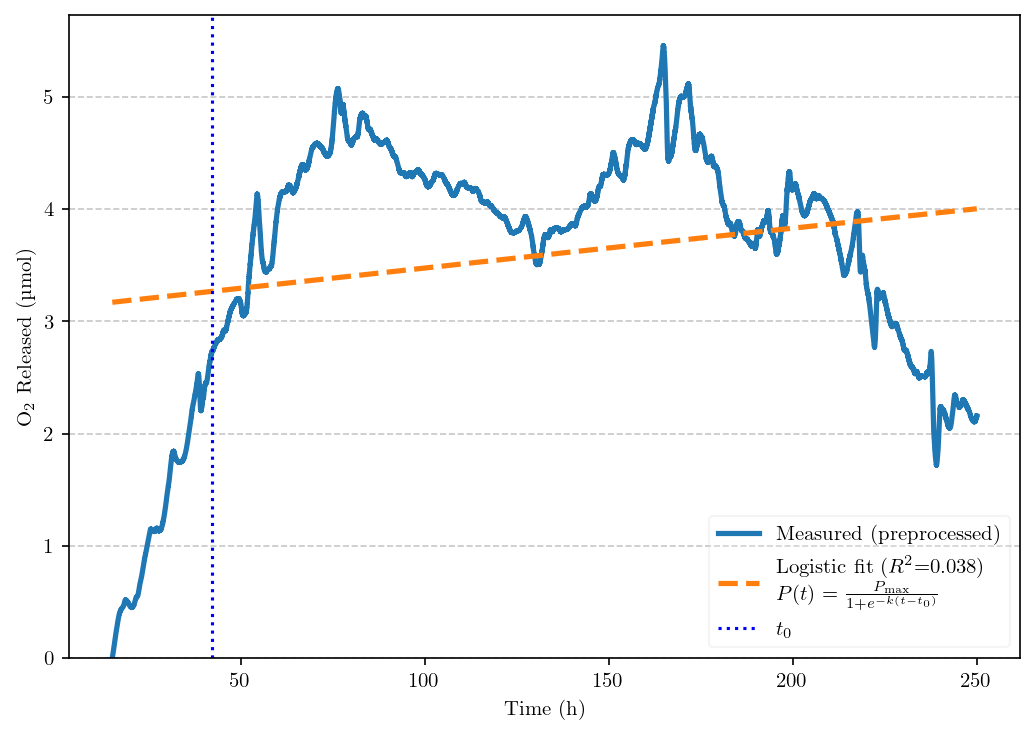

In [50]:

m3logi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\RT\Data files\M3_1.2mM_RT_pressure_o2_release.csv"
df_m3logi = pd.read_csv(m3logi_csv)
df_m3logi.columns = [c.strip() for c in df_m3logi.columns]

# # Replace these with the series/column you want to fit
# ngas_m3logi = df_m3logi["O2 Released (µmol)"].values
# time_m3logi = df_m3logi["Time (h)"].values



df_m3logi_pos = df_m3logi[df_m3logi["O2 Released (µmol)"] > 0].reset_index(drop=True)

ngas_m3logi = df_m3logi_pos["O2 Released (µmol)"].values
time_m3logi = df_m3logi_pos["Time (h)"].values


# --- Clean NaNs/Infs ---
mask = np.isfinite(time_m3logi) & np.isfinite(ngas_m3logi)
t = np.asarray(time_m3logi[mask], dtype=float)
y = np.asarray(ngas_m3logi[mask], dtype=float)

# --- Logistic model ---
def logistic_model(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))

# --- Fit function with bounds from table ---
def fit_logistic_model(time, signal):
    P_max = np.max(signal)
    # initial guess for t0 = time at ~half max
    P0_init = time[np.argmin(np.abs(signal - P_max / 2.0))]
    k_init = 1.0 / (time[-1] - time[0] + 1e-9)  # avoid div/0
    
    # bounds according to table:
    # t0: [0.8 * P0_init, 1.2 * P0_init]
    # k: [0, 1]
    # P_max: [0.8 * P_max, 1.2 * P_max]
    bounds = [
        (0.8 * P0_init, 1.2 * P0_init),
        (0.0, 1.0),
        (0.8 * P_max, 1.2 * P_max)
    ]
    
    res = minimize(
        lambda p: mean_squared_error(signal, logistic_model(time, *p)),
        [P0_init, k_init, P_max],
        bounds=bounds
    )
    popt = res.x
    fit = logistic_model(time, *popt)
    return popt, fit

# --- Run fit ---
popt, y_fit = fit_logistic_model(t, y)
t0_fit, k_fit, Pmax_fit = popt

# --- Metrics ---
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 3
bic = n * np.log(rss / n) + 3 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Logistic (bounded)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/h)": [k_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic]
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic fit ($R^2$={r2:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit, linestyle=":", color="blue", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

Bounds too restrcitive

Changed guesses and bounds:

1. Instead of t0 = Pmax/2, it is set to point of maximum slope.
2. Initial guess for K was K = 1/time span
instead the regular logistic property for slope at inflection point is k.pmax/4. so k = 4.slopemax / pmax.

3. instead of to being, it is between tmin and tmax

# Modified logistic

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC,Converged
0,Logistic (robust),4.386141,0.066795,36.765951,0.40878,0.885367,-964281.617595,-964248.025394,True


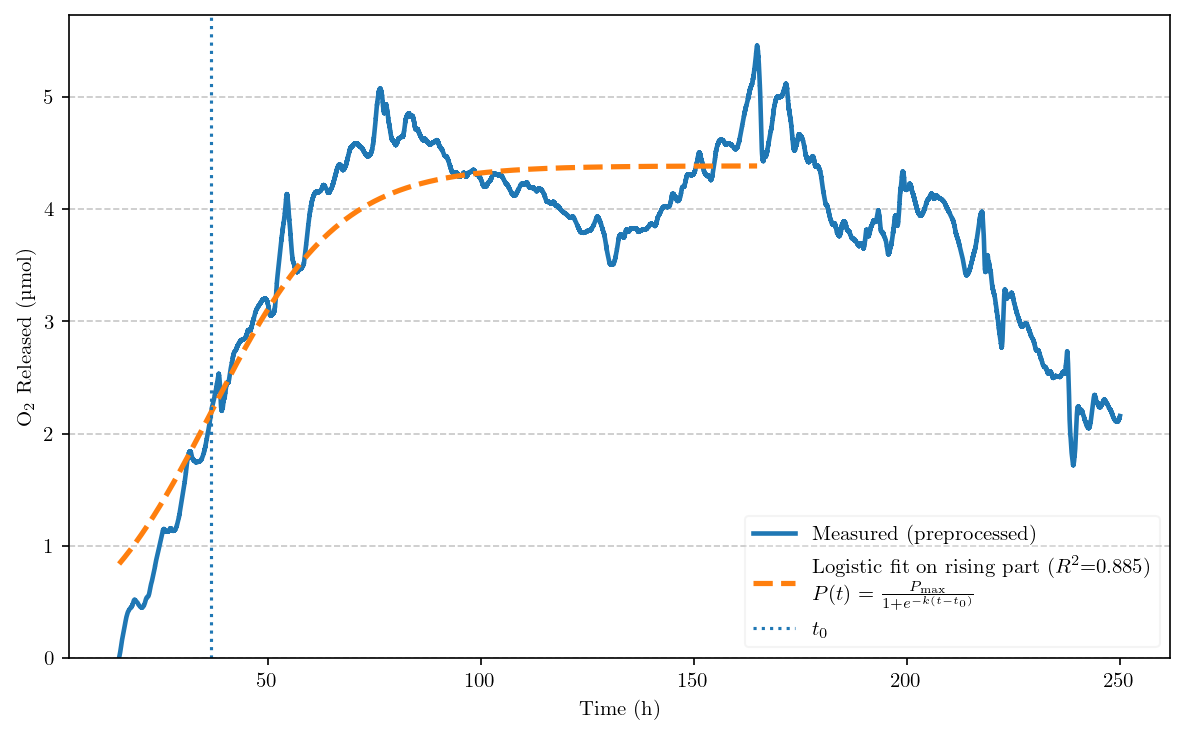

In [ ]:


m3logi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\RT\Data files\M3_1.2mM_RT_pressure_o2_release.csv"
df_m3logi = pd.read_csv(m3logi_csv)
df_m3logi.columns = [c.strip() for c in df_m3logi.columns]

# Keep only positive O2 rows so time & signal stay aligned
df_m3logi_pos = df_m3logi[df_m3logi["O2 Released (µmol)"] > 0].reset_index(drop=True)
t_full = df_m3logi_pos["Time (h)"].to_numpy(dtype=float)
y_full = df_m3logi_pos["O2 Released (µmol)"].to_numpy(dtype=float)


mask = np.isfinite(t_full) & np.isfinite(y_full)
t_full = t_full[mask]
y_full = y_full[mask]

.
idx_peak = np.argmax(y_full)
t = t_full[: idx_peak + 1]
y = y_full[: idx_peak + 1]


def logistic_model(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))


span = max(t.max() - t.min(), 1e-6)
Pmax0 = np.quantile(y, 0.98)  

# smooth just for slope estimation (doesn't affect fit)
win = max(5, int(0.03 * len(y)))  # ~3% of points
if win % 2 == 0:
    win += 1
y_smooth = pd.Series(y).rolling(window=win, center=True, min_periods=1).mean().to_numpy()
dy_dt = np.gradient(y_smooth, t)
i_inflect = int(np.argmax(dy_dt))
t0_init = float(t[i_inflect])
slope_max = float(max(dy_dt[i_inflect], 1e-12))  # avoid 0


# For logistic, slope at inflection ≈ k * Pmax / 4 -> k ≈ 4*slope/Pmax
k_init = float(4.0 * slope_max / max(Pmax0, 1e-9))
# keep k_init within a sane range w.r.t span
k_init = np.clip(k_init, 1e-6, 10.0 / span)


bounds = [
    (t.min(), t.max()),                 
    (1e-6, 10.0 / span),                
    (0.5 * Pmax0, 2.0 * max(y))         
]


def fit_logistic_model(time, signal):
    def obj(p):
        return mean_squared_error(signal, logistic_model(time, *p))
    x0 = np.array([t0_init, k_init, Pmax0], dtype=float)
    res = minimize(obj, x0, bounds=bounds, method="L-BFGS-B")
    # If optimizer struggles, fall back to a gentler start
    if not res.success:
        alt_x0 = np.array([np.median(time), 1.0 / span, np.max(signal)], dtype=float)
        res = minimize(obj, alt_x0, bounds=bounds, method="L-BFGS-B")
    popt = res.x
    fit = logistic_model(time, *popt)
    return popt, fit, res

popt, y_fit, res = fit_logistic_model(t, y)
t0_fit, k_fit, Pmax_fit = popt

# ---- Metrics ----
rss = np.sum((y - y_fit) ** 2)
rmse = float(np.sqrt(mean_squared_error(y, y_fit)))
r2 = float(r2_score(y, y_fit))
n = len(y)
aic = float(n * np.log(rss / n + 1e-12) + 2 * 3)
bic = float(n * np.log(rss / n + 1e-12) + 3 * np.log(max(n, 2)))

metrics = pd.DataFrame({
    "Model": ["Logistic (robust)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/h)": [k_fit],
    "t0 (h)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic],
    "Converged": [bool(res.success)]
})
display(metrics.round(6))


plt.figure(figsize=(8, 5), dpi=150)
plt.plot(t_full, y_full, label="Measured (preprocessed)", lw=2.2)  # show full series for context
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic fit on rising part ($R^2$={r2:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# Gompertz

# M3 - 1.2mM @ 37 C

## First order

,Model,P_max (µmol),k (1/h),Half-Life (s),Half-Life (h),RMSE (µmol),R²,AIC,BIC
0,First-order,6.785743,0.139026,17948.707175,4.985752,0.301696,0.954867,-614137.970475,-614117.062673


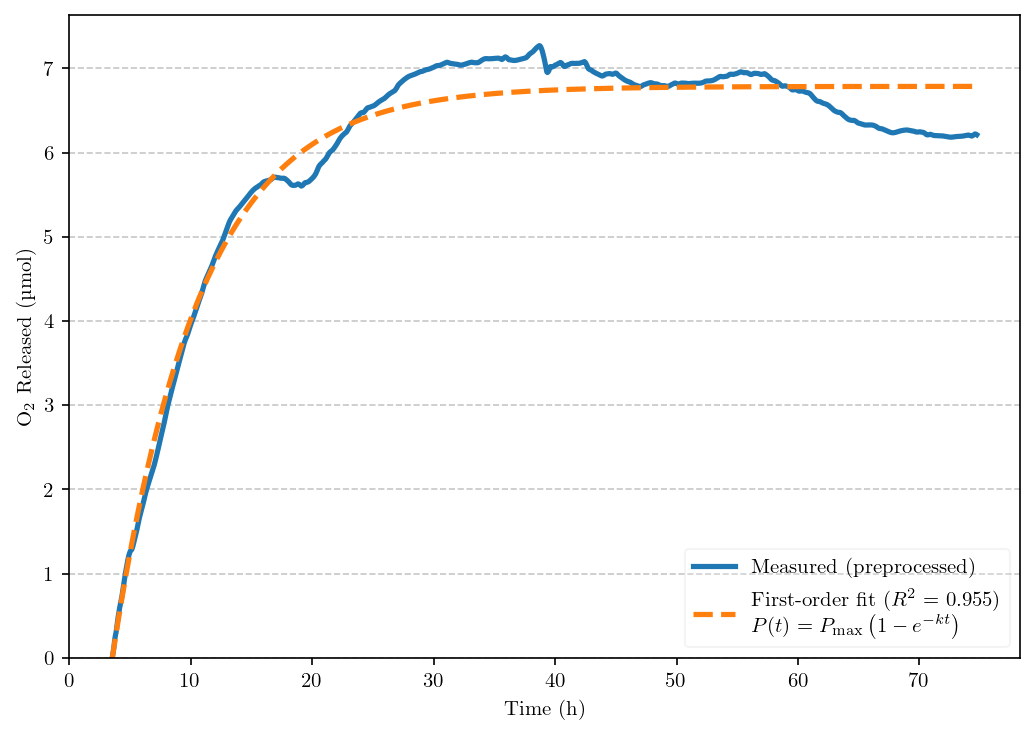

In [41]:
m33_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\37 C\Data files\M3_CROPPED.csv"
df_m33 = pd.read_csv(m33_csv)
df_m33.columns = [c.strip() for c in df_m33.columns]

# Replace these with the series/column you want to fit
ngas_m33 = df_m33["O2 Released (µmol)"].values
time_m33 = df_m33["Time (h)"].values


# --- Clean: drop NaNs/Infs and ensure strictly increasing time (if needed) ---
mask = np.isfinite(time_m33) & np.isfinite(ngas_m33)
t = np.asarray(time_m33[mask], dtype=float)
y = np.asarray(ngas_m33[mask], dtype=float)

# If times are not strictly increasing, sort them (and y accordingly)
if np.any(np.diff(t) <= 0):
    order = np.argsort(t)
    t, y = t[order], y[order]

# Optionally, shift time to start at 0 for numerical stability (doesn't change k)
t0 = t.min()
t = t - t0

# --- First-order model ---
def first_order_model(t, P_max, k):
    # P(t) = P_max * (1 - exp(-k t))
    return P_max * (1.0 - np.exp(-k * t))

# --- Fit: robust initial guesses + nonnegative bounds ---
Pmax0 = float(np.nanmax(y))
dt = max(t.max() - t.min(), 1.0)  # seconds span; guard against zero
# choose half-life ~ 30% of data span as a reasonable default
k0 = np.log(2.0) / (0.3 * dt)
k0 = max(k0, 1e-9)

popt, pcov = curve_fit(
    first_order_model, t, y,
    p0=[Pmax0 if np.isfinite(Pmax0) and Pmax0 > 0 else (y[-1] if len(y) else 1.0), k0],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
    maxfev=20000
)
P_max_fit, k_fit = popt
y_fit = first_order_model(t, *popt)

# --- Metrics (first-order only) ---
def aic(n, rss, k_params):
    return n * np.log(rss / n) + 2 * k_params

def bic(n, rss, k_params):
    return n * np.log(rss / n) + k_params * np.log(n)

n = len(y)
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
aic_val = aic(n, rss, 2)  # params: P_max, k
bic_val = bic(n, rss, 2)
t_half_h = np.log(2.0) / k_fit
t_half_s = t_half_h * 3600.0

# --- Show metrics ---
metrics = pd.DataFrame({
    "Model": ["First-order"],
    "P_max (µmol)": [P_max_fit],
    "k (1/h)": [k_fit],
    "Half-Life (s)": [t_half_s],
    "Half-Life (h)": [t_half_h],
    "RMSE (µmol)": [rmse],
    "R²": [r2],
    "AIC": [aic_val],
    "BIC": [bic_val],
})
display(metrics.round(6))

# --- Plot (Plot #3 analog: data + first-order fit only) ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t + t0, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t + t0, y_fit, "--", lw=2.5,
         label=fr"First-order fit ($R^2$ = {r2:.3f})" + "\n" + r"$P(t)=P_{\max}\left(1-e^{-kt}\right)$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.xlim()
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Logistic

,Model,P_max (µmol),k (1/s),t0 (s),RMSE,R²,AIC,BIC
0,Logistic (bounded),6.722216,0.26608,9.386009,0.331529,0.9455,-565810.033038,-565778.671335


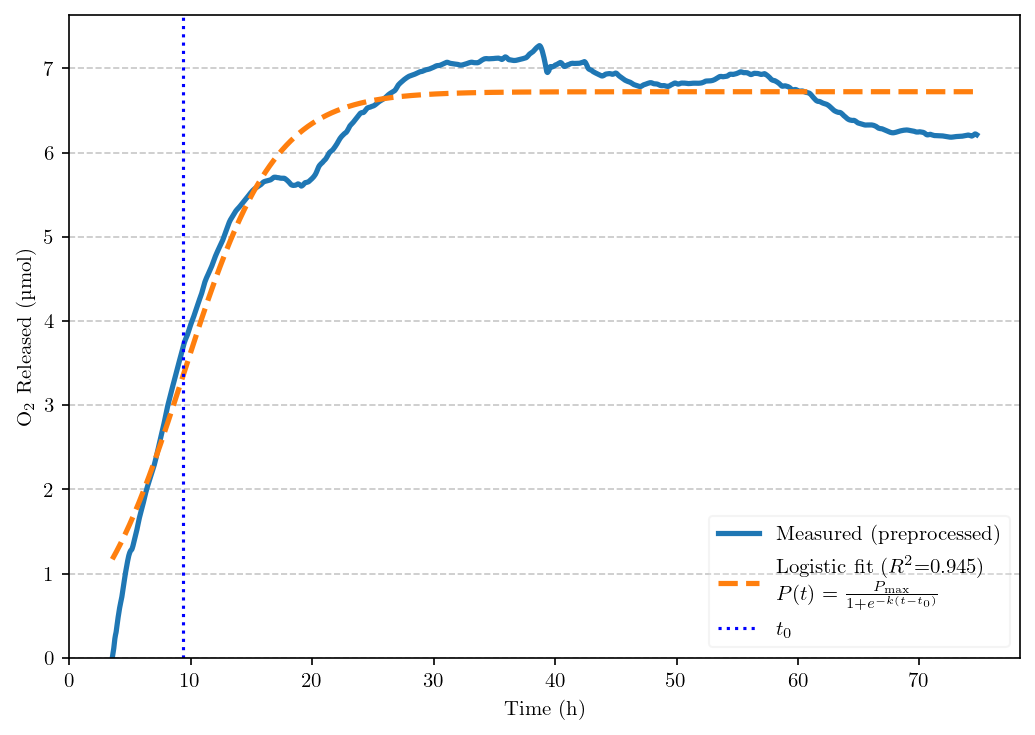

In [26]:
m33logi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\37 C\Data files\M3_CROPPED.csv"
df_m33logi = pd.read_csv(m33logi_csv)
df_m33logi.columns = [c.strip() for c in df_m33logi.columns]

# Replace these with the series/column you want to fit
ngas_m33logi = df_m33logi["O2 Released (µmol)"].values
time_m33logi = df_m33logi["Time (h)"].values

# --- Clean NaNs/Infs ---
mask = np.isfinite(time_m33logi) & np.isfinite(ngas_m33logi)
t = np.asarray(time_m33logi[mask], dtype=float)
y = np.asarray(ngas_m33logi[mask], dtype=float)

# --- Logistic model ---
def logistic_model(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))

# --- Fit function with bounds from table ---
def fit_logistic_model(time, signal):
    P_max = np.max(signal)
    # initial guess for t0 = time at ~half max
    P0_init = time[np.argmin(np.abs(signal - P_max / 2.0))]
    k_init = 1.0 / (time[-1] - time[0] + 1e-9)  # avoid div/0
    
    # bounds according to table:
    # t0: [0.8 * P0_init, 1.2 * P0_init]
    # k: [0, 1]
    # P_max: [0.8 * P_max, 1.2 * P_max]
    bounds = [
        (0.8 * P0_init, 1.2 * P0_init),
        (0.0, 1.0),
        (0.8 * P_max, 1.2 * P_max)
    ]
    
    res = minimize(
        lambda p: mean_squared_error(signal, logistic_model(time, *p)),
        [P0_init, k_init, P_max],
        bounds=bounds
    )
    popt = res.x
    fit = logistic_model(time, *popt)
    return popt, fit

# --- Run fit ---
popt, y_fit = fit_logistic_model(t, y)
t0_fit, k_fit, Pmax_fit = popt

# --- Metrics ---
rss = np.sum((y - y_fit) ** 2)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
n = len(y)
aic = n * np.log(rss / n) + 2 * 3
bic = n * np.log(rss / n) + 3 * np.log(n)

metrics = pd.DataFrame({
    "Model": ["Logistic (bounded)"],
    "P_max (µmol)": [Pmax_fit],
    "k (1/s)": [k_fit],
    "t0 (s)": [t0_fit],
    "RMSE": [rmse],
    "R²": [r2],
    "AIC": [aic],
    "BIC": [bic]
})
display(metrics.round(6))

# --- Plot ---
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(t, y, label="Measured (preprocessed)", lw=2.5)
plt.plot(t, y_fit, "--", lw=2.5,
         label=fr"Logistic fit ($R^2$={r2:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit, linestyle=":", color="blue", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()

# Checking for modified bounds - Modified logistic

,Model,P_max (µmol),k (1/h),t0 (h),RMSE,R²,AIC,BIC,Converged
0,Logistic (robust),6.87581,0.242534,9.639372,0.345239,0.963795,-269268.257041,-269239.010773,True


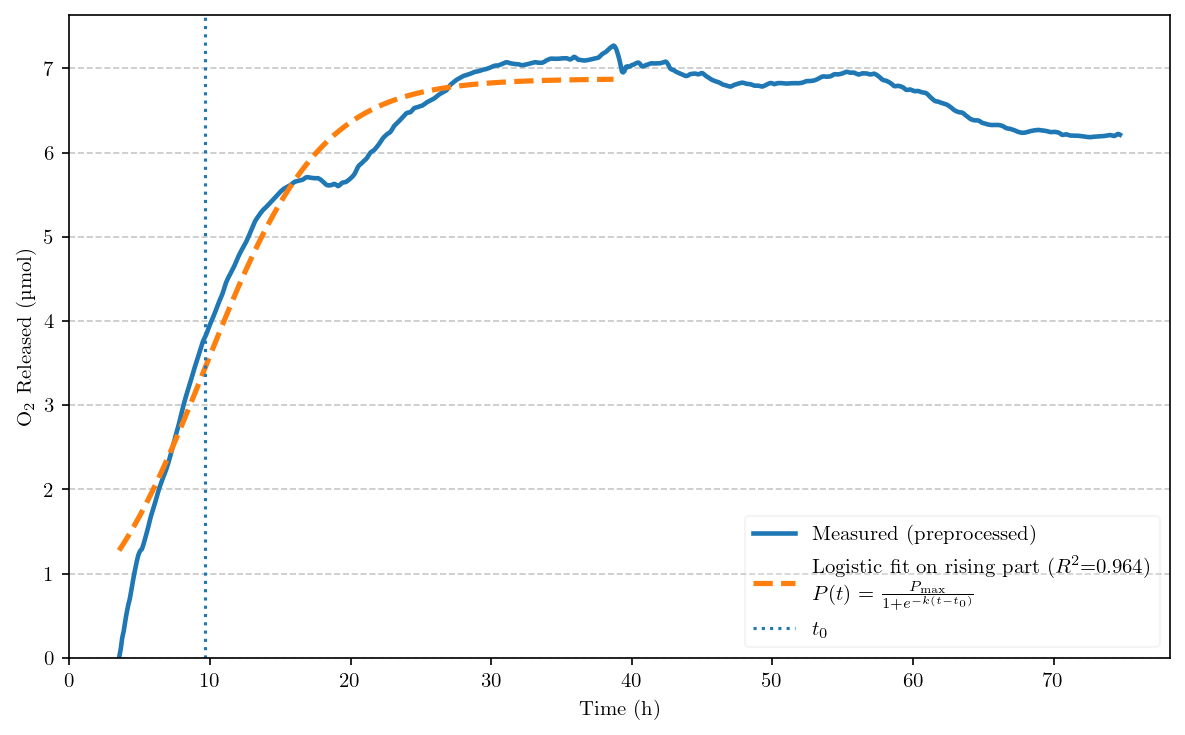

In [51]:

# --- Load CSV ---
m331logi_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M3-1.2mM\Pressure\37 C\Data files\M3_CROPPED.csv"
df_m331logi = pd.read_csv(m331logi_csv)
df_m331logi.columns = [c.strip() for c in df_m331logi.columns]

# Extract arrays
ngas_m331logi = df_m331logi["O2 Released (µmol)"].to_numpy(dtype=float)
time_m331logi = df_m331logi["Time (h)"].to_numpy(dtype=float) 

# --- Clean NaNs/Infs ---
mask = np.isfinite(time_m331logi) & np.isfinite(ngas_m331logi)
t_full_m331 = time_m331logi[mask]
y_full_m331 = ngas_m331logi[mask]

# --- Trim to rising part only (up to peak) ---
idx_peak = np.argmax(y_full_m331)
t_m331 = t_full_m331[: idx_peak + 1]
y_m331 = y_full_m331[: idx_peak + 1]

# --- Logistic model ---
def logistic_model_m331(t, t0, k, P_max):
    return P_max / (1.0 + np.exp(-k * (t - t0)))

# --- Initial guesses ---
span_m331 = max(t_m331.max() - t_m331.min(), 1e-6)
Pmax0_m331 = np.quantile(y_m331, 0.98)

# Smooth only for slope estimation
win = max(5, int(0.03 * len(y_m331)))
if win % 2 == 0:
    win += 1
y_smooth_m331 = pd.Series(y_m331).rolling(window=win, center=True, min_periods=1).mean().to_numpy()
dy_dt_m331 = np.gradient(y_smooth_m331, t_m331)
i_inflect_m331 = int(np.argmax(dy_dt_m331))
t0_init_m331 = float(t_m331[i_inflect_m331])
slope_max_m331 = float(max(dy_dt_m331[i_inflect_m331], 1e-12))

k_init_m331 = float(4.0 * slope_max_m331 / max(Pmax0_m331, 1e-9))
k_init_m331 = np.clip(k_init_m331, 1e-6, 10.0 / span_m331)

# --- Bounds ---
bounds_m331 = [
    (t_m331.min(), t_m331.max()), 
    (1e-6, 10.0 / span_m331), 
    (0.5 * Pmax0_m331, 2.0 * max(y_m331))
]

# --- Fit ---
def fit_logistic_model_m331(time, signal):
    def obj(p):
        return mean_squared_error(signal, logistic_model_m331(time, *p))
    x0 = np.array([t0_init_m331, k_init_m331, Pmax0_m331], dtype=float)
    res = minimize(obj, x0, bounds=bounds_m331, method="L-BFGS-B")
    if not res.success:
        alt_x0 = np.array([np.median(time), 1.0 / span_m331, np.max(signal)], dtype=float)
        res = minimize(obj, alt_x0, bounds=bounds_m331, method="L-BFGS-B")
    popt = res.x
    fit = logistic_model_m331(time, *popt)
    return popt, fit, res

popt_m331, y_fit_m331, res_m331 = fit_logistic_model_m331(t_m331, y_m331)
t0_fit_m331, k_fit_m331, Pmax_fit_m331 = popt_m331

# --- Metrics ---
rss_m331 = np.sum((y_m331 - y_fit_m331) ** 2)
rmse_m331 = np.sqrt(mean_squared_error(y_m331, y_fit_m331))
r2_m331 = r2_score(y_m331, y_fit_m331)
n_m331 = len(y_m331)
aic_m331 = n_m331 * np.log(rss_m331 / n_m331 + 1e-12) + 2 * 3
bic_m331 = n_m331 * np.log(rss_m331 / n_m331 + 1e-12) + 3 * np.log(max(n_m331, 2))

metrics_m331 = pd.DataFrame({
    "Model": ["Logistic (robust)"],
    "P_max (µmol)": [Pmax_fit_m331],
    "k (1/h)": [k_fit_m331],
    "t0 (h)": [t0_fit_m331],
    "RMSE": [rmse_m331],
    "R²": [r2_m331],
    "AIC": [aic_m331],
    "BIC": [bic_m331],
    "Converged": [bool(res_m331.success)]
})
display(metrics_m331.round(6))

# --- Plot ---
plt.figure(figsize=(8, 5), dpi=150)
plt.plot(t_full_m331, y_full_m331, label="Measured (preprocessed)", lw=2.2)
plt.plot(t_m331, y_fit_m331, "--", lw=2.5,
         label=fr"Logistic fit on rising part ($R^2$={r2_m331:.3f})" + "\n" + r"$P(t)=\frac{P_{\max}}{1+e^{-k(t-t_0)}}$")
plt.axvline(t0_fit_m331, linestyle=":", label=r"$t_0$")
plt.xlabel("Time (h)")
plt.ylabel("O$_2$ Released (µmol)")
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right", frameon=True, framealpha=0.2)
plt.tight_layout()
plt.show()


# Gompertz